# LeetCode #49: Group Anagrams

https://leetcode.com/problems/group-anagrams/

## Comparison of Approaches

| Approach | Time | Space |
| :--- | :--- | :--- |
| **Sort each string** | $O(n \cdot k \log k)$ | $O(n \cdot k)$ |
| **Char-Count Key** ★ | $O(n \cdot k)$ | $O(n \cdot k)$ |

---

## Understanding the Methods

### Sort Key
For each string, sort it (O(k log k)) and use the sorted string as the HashMap key. All anagrams sort to the same string. Simple but slower.

### Optimal: Char-Count Key ★
For each string, build a 26-element integer array `count[26]` where `count[i]` = frequency of 'a'+i. Convert to a canonical string key (e.g., `"1,0,0,...,1,...,1,..."`). All anagrams produce identical count arrays and thus identical keys. O(k) per word instead of O(k log k).

**Constraints:**
* $1 \leq$ strs.length $\leq 10^4$
* $0 \leq$ strs[i].length $\leq 100$
* strs[i] consists of lowercase English letters

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<IList<string>> GroupAnagrams(string[] strs) {
        var map = new Dictionary<string, List<string>>();
        foreach (string s in strs) {
            var count = new int[26];
            foreach (char c in s) count[c - 'a']++;
            string key = string.Join(",", count);
            if (!map.ContainsKey(key)) map[key] = new List<string>();
            map[key].Add(s);
        }
        return new List<IList<string>>(map.Values);
    }
}

### Python

In [ ]:
from typing import List
from collections import defaultdict

class Solution:
    def groupAnagrams(self, strs: List[str]) -> List[List[str]]:
        groups = defaultdict(list)
        for s in strs:
            count = [0] * 26
            for c in s:
                count[ord(c) - ord('a')] += 1
            groups[tuple(count)].append(s)
        return list(groups.values())

### Go

In [ ]:
package main

import "fmt"

func groupAnagrams(strs []string) [][]string {
	groups := map[[26]int][]string{}
	for _, s := range strs {
		var count [26]int
		for _, c := range s {
			count[c-'a']++
		}
		groups[count] = append(groups[count], s)
	}
	result := make([][]string, 0, len(groups))
	for _, g := range groups {
		result = append(result, g)
	}
	_ = fmt.Sprintf // satisfy import
	return result
}

### Rust

In [ ]:
use std::collections::HashMap;

pub struct Solution;

impl Solution {
    pub fn group_anagrams(strs: Vec<String>) -> Vec<Vec<String>> {
        let mut map: HashMap<[u32; 26], Vec<String>> = HashMap::new();
        for s in strs {
            let mut count = [0u32; 26];
            for b in s.bytes() {
                count[(b - b'a') as usize] += 1;
            }
            map.entry(count).or_default().push(s);
        }
        map.into_values().collect()
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `strs = ["eat", "tea", "tan", "ate", "nat", "bat"]`

Walk through: Build a 26-element count array for each word. "eat", "tea", "ate" all produce `{a:1, e:1, t:1}` → same key → one group. "tan", "nat" → `{a:1, n:1, t:1}`. "bat" → `{a:1, b:1, t:1}`.

**Why tricky:** Baseline case to verify the count-key approach works. Interviewers confirm you can articulate why count-key is $O(n \cdot k)$ vs sort-key's $O(n \cdot k \log k)$.

### 2. Slightly Complex — Repeated Characters and Mixed Lengths
**Input:** `strs = ["aab", "aba", "baa", "ab", "ba", "aaab"]`

Walk through: "aab"/"aba"/"baa" all have `{a:2, b:1}` → one group. "ab"/"ba" have `{a:1, b:1}` → different group. "aaab" has `{a:3, b:1}` → its own group. Despite similar characters, frequency differences keep groups separate.

**Why tricky:** Repeated characters mean sorting still works but count-key avoids the $O(k \log k)$ sort per word. Interviewers check that you handle duplicate letters — "aab" vs "ab" differ only in the 'a' frequency.

### 3. Edge Case: Time Factor — Maximum Input ($n = 10^4$, $k = 100$, All Anagrams)
**Input:** 10,000 strings, each 100 characters long, all anagrams of each other

Walk through: Sort-key approach: $10{,}000 \times 100 \times \log(100) \approx 6.65 \times 10^6$ operations. Count-key approach: $10{,}000 \times 100 = 10^6$ operations — $\approx 6.6\times$ faster. All strings map to one bucket containing 10,000 entries.

**Why tricky:** At maximum constraints, the constant-factor difference between $O(k \log k)$ and $O(k)$ per word becomes measurable. Interviewers want concrete numbers showing why count-key wins.

### 4. Edge Case: Space Factor — All Unique (No Anagrams)
**Input:** `strs = ["a", "bb", "ccc", "dddd", ...]` — 10,000 unique-length strings

Walk through: Every word has a unique count key → 10,000 singleton groups. The HashMap stores 10,000 entries, each with a 26-int key and a list of one string. Total memory $\approx O(n \cdot k)$.

**Why tricky:** Worst case for space: no grouping occurs, so the HashMap is as large as the input. The output itself is $O(n \cdot k)$ — you cannot beat that. Interviewers verify you understand that space is dominated by the output, not the algorithm.

### 5. Almost-Impossible but Plausible — Empty Strings
**Input:** `strs = ["", "", "a", "", "a"]`

Walk through: Empty strings have count array = all zeros, which is a valid HashMap key. All three "" strings group together. The two "a" strings group together. Output: `[["","",""], ["a","a"]]`.

**Why tricky:** Many candidates forget that empty strings are valid input ($0 \leq$ strs[i].length). The all-zeros count array is a perfectly valid key. Some implementations crash on length-0 strings. Interviewers use this to test boundary handling.

---

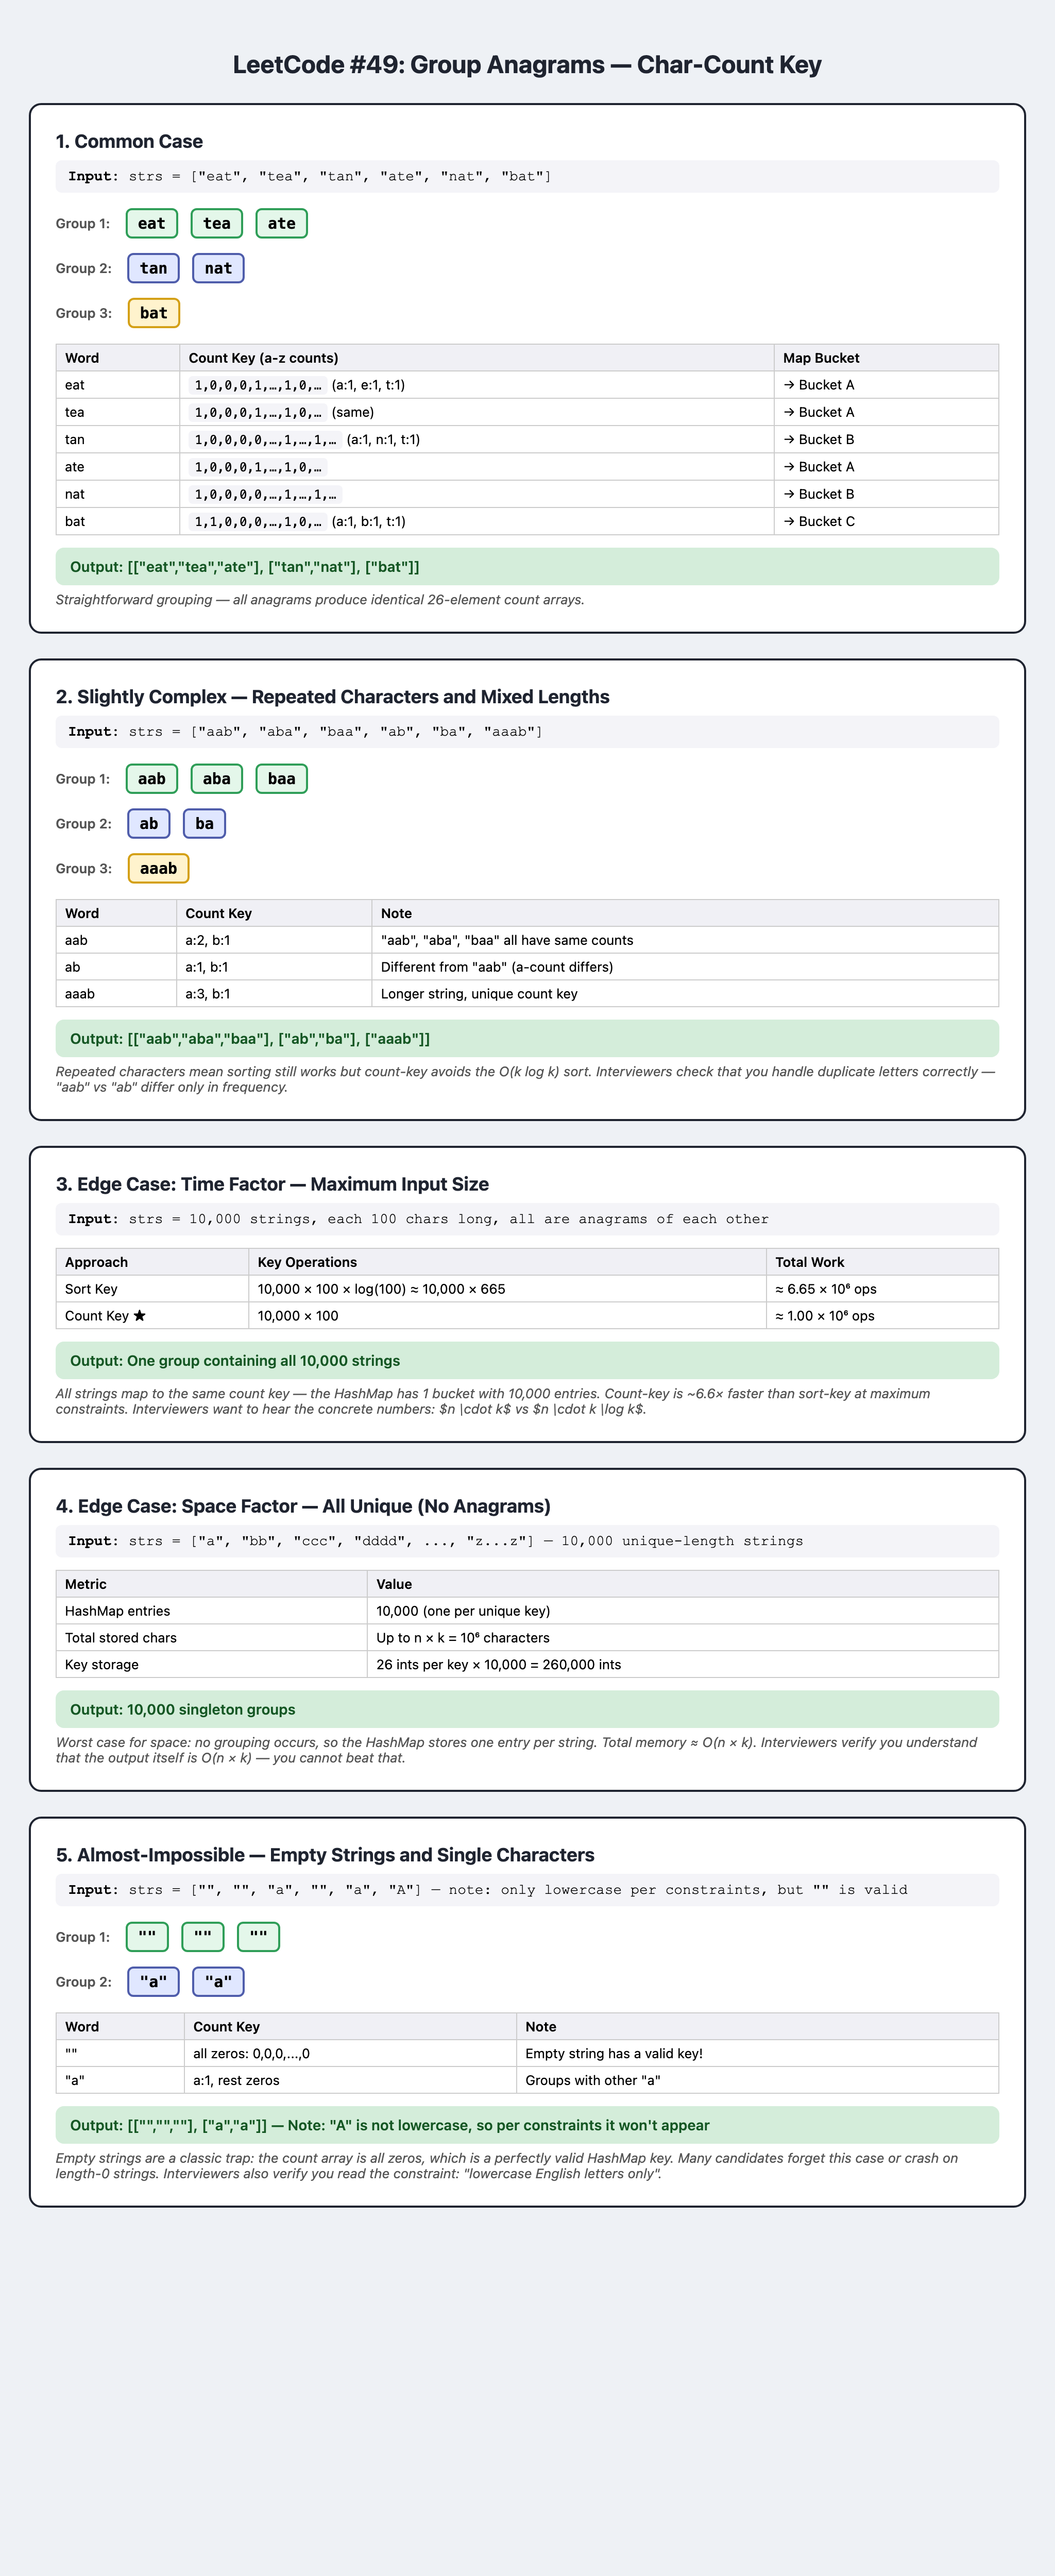